<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_3_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 3: Developing a Binary Classification Model for Disease Risk Prediction using ANN

This notebook demonstrates how to build an Artificial Neural Network (ANN) for binary classification. We will use the Breast Cancer dataset to predict whether a tumor is malignant or benign based on its features.

In [ ]:
import tensorflow as tf
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Data Loading and Preprocessing
We load the dataset, split it into training and testing sets, and standardize the features. Standardization is crucial for neural networks to ensure all input features are on a similar scale.

In [ ]:
# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training features shape: {X_train_scaled.shape}')
print(f'Testing features shape: {X_test_scaled.shape}')

Training features shape: (455, 30)
Testing features shape: (114, 30)


### 2. Building the ANN Model
We construct a Sequential model with fully connected (Dense) layers. The hidden layers use the ReLU activation function. For binary classification, the final output layer must have a single neuron with a 'sigmoid' activation function to output a probability between 0 and 1.

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    # Output layer for binary classification
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compiling and Training the Model
We use the 'adam' optimizer and 'binary_crossentropy' as the loss function, which is the standard choice for binary classification tasks.

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5907 - loss: 0.6802 - val_accuracy: 0.9121 - val_loss: 0.4466
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8846 - loss: 0.4083 - val_accuracy: 0.9560 - val_loss: 0.2802
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9286 - loss: 0.2642 - val_accuracy: 0.9670 - val_loss: 0.2003
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9451 - loss: 0.1887 - val_accuracy: 0.9780 - val_loss: 0.1591
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9643 - loss: 0.1450 - val_accuracy: 0.9780 - val_loss: 0.1393
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9753 - loss: 0.1186 - val_accuracy: 0.9670 - val_loss: 0.1285
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.1009 - val_accuracy: 0.9670 - val_loss: 0.1212
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9808 - loss: 0.0889 - val_accuracy: 0.9670 - val_loss

### 4. Evaluating the Model
Finally, we evaluate the trained model on the unseen test dataset to determine its accuracy in predicting disease risk.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\nTest Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')


Test Accuracy: 0.9737
Test Loss: 0.0941


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


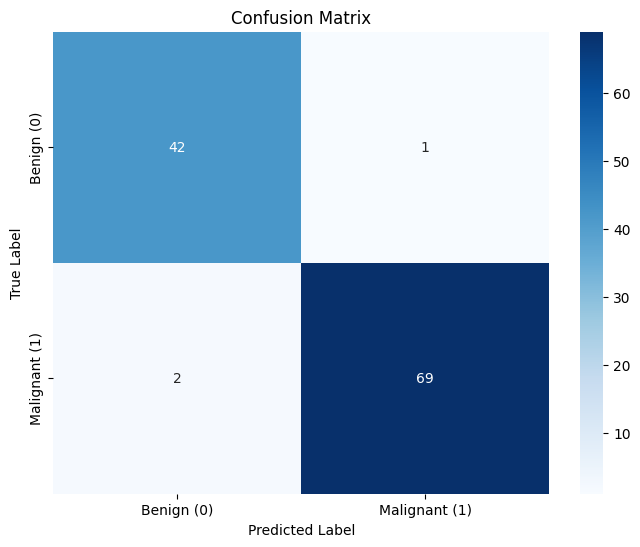

In [ ]:
# Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()